<a href="https://colab.research.google.com/github/Fegel12/Unab/blob/main/1_7_EDA_en_datos_categ%C3%B3ricos_Fergel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



<img src="https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/102012/logo_unab.png?itok=hZ5x30O2" width="240" height="240" align="right"/>


<center><h1>Estadística para la Ciencia de Datos</header1></center>
<left><h1>Unidad 1: Análisis exploratorio de datos</header1></left>

# Paquetes básicos a ser usados

In [1]:
# paquetes necesarios en esta sección
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA en datos categóricos

In [2]:
path = 'https://raw.githubusercontent.com/JSebasB90/datasets/refs/heads/main/divorce.csv'

In [3]:
df1 =  pd.read_csv(path)

In [4]:
df1.head()

,divorce_date,dob_man,education_man,income_man,dob_woman,education_woman,income_woman,marriage_date,marriage_duration,num_kids
0,2006-09-06,1975-12-18,Secondary,2000.0,1983-08-01,Secondary,1800.0,2000-06-26,5.0,1.0
1,2008-01-02,1976-11-17,Professional,6000.0,1977-03-13,Professional,6000.0,2001-09-02,7.0,NaN
2,2011-01-02,1969-04-06,Preparatory,5000.0,1970-02-16,Professional,5000.0,2000-02-02,2.0,2.0
3,2011-01-02,1979-11-13,Secondary,12000.0,1981-05-13,Secondary,12000.0,2006-05-13,2.0,NaN
4,2011-01-02,1982-09-20,Professional,6000.0,1988-01-30,Professional,10000.0,2007-08-06,3.0,NaN


Vamos a reemplazar los NaNs de `num_kids`por 0

In [5]:
df1['num_kids'] = df1['num_kids'].fillna(0)

In [6]:
df1.shape

(2209, 10)

In [7]:
df1.isna().sum()

,0
divorce_date,0
dob_man,0
education_man,4
income_man,0
dob_woman,0
education_woman,0
income_woman,0
marriage_date,0
marriage_duration,0
num_kids,0


## Variables catégoricas

Categórico:

- Número finito de grupos (o categorías)
- Estas categorías suelen ser fijas o conocidas (color de ojos, color de pelo, etc.)
- Se conocen como datos cualitativos

Numérico:

- Se conocen como datos cuantitativos
- Se expresan mediante un valor numérico
- Suele ser una medida (altura, peso, coeficiente intelectual, etc.)

Por ejemplo, nuestro dataset tiene estas variables:

In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209 entries, 0 to 2208
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   divorce_date       2209 non-null   object 
 1   dob_man            2209 non-null   object 
 2   education_man      2205 non-null   object 
 3   income_man         2209 non-null   float64
 4   dob_woman          2209 non-null   object 
 5   education_woman    2209 non-null   object 
 6   income_woman       2209 non-null   float64
 7   marriage_date      2209 non-null   object 
 8   marriage_duration  2209 non-null   float64
 9   num_kids           2209 non-null   float64
dtypes: float64(4), object(6)
memory usage: 172.7+ KB


En nuestro caso no son muchos los gráficos que podemos hacer, salvo countplots, en este caso veamos el de `education_woman`

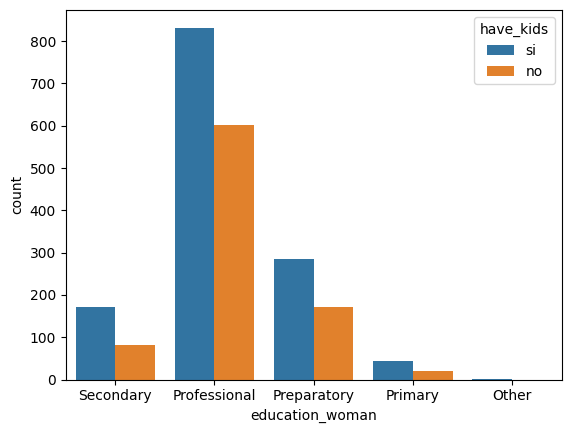

In [16]:
df1['have_kids'] = df1['num_kids'].apply(lambda x: 'si' if x>0 else 'no')
sns.countplot(data=df1, x='education_woman', hue='have_kids')
plt.show()

Podemos crear categorías de  las variables numéricas, por ejemplo si tiene hijos:

In [12]:
df1['have_kids'] = df1['num_kids'].apply(lambda x: 'si' if x>0 else 'no')

In [13]:
df1.head()

,divorce_date,dob_man,education_man,income_man,dob_woman,education_woman,income_woman,marriage_date,marriage_duration,num_kids,have_kids
0,2006-09-06,1975-12-18,Secondary,2000.0,1983-08-01,Secondary,1800.0,2000-06-26,5.0,1.0,si
1,2008-01-02,1976-11-17,Professional,6000.0,1977-03-13,Professional,6000.0,2001-09-02,7.0,0.0,no
2,2011-01-02,1969-04-06,Preparatory,5000.0,1970-02-16,Professional,5000.0,2000-02-02,2.0,2.0,si
3,2011-01-02,1979-11-13,Secondary,12000.0,1981-05-13,Secondary,12000.0,2006-05-13,2.0,0.0,no
4,2011-01-02,1982-09-20,Professional,6000.0,1988-01-30,Professional,10000.0,2007-08-06,3.0,0.0,no


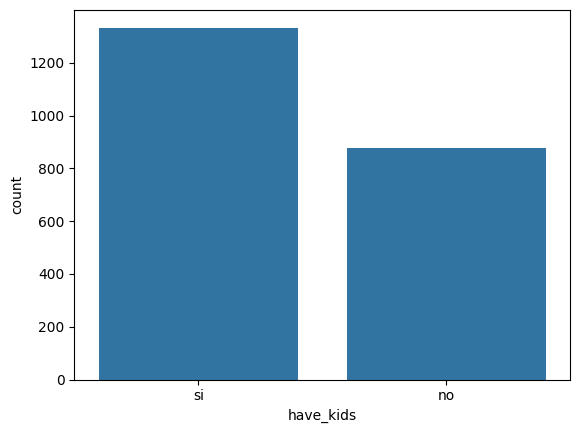

In [14]:
sns.countplot(data=df1, x='have_kids')
plt.show()

También se pueden hacer tablas cruzadas con las variables categóricas:

In [ ]:
pd.pivot_table(data=df1, index='education_man', columns='education_woman', values='marriage_duration', aggfunc='mean', fill_value=0)

education_woman,Other,Preparatory,Primary,Professional,Secondary
education_man,,,,,
Other,0.0,0.000000,0.000000,4.000000,13.000000
Preparatory,0.0,8.708995,12.700000,9.646552,10.842857
Primary,0.0,10.185185,12.866667,10.714286,12.862069
Professional,9.0,9.600000,9.000000,9.236627,11.687500
Secondary,2.0,8.202381,13.944444,10.585366,10.757282


## Manejo de Fechas

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209 entries, 0 to 2208
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   divorce_date       2209 non-null   object 
 1   dob_man            2209 non-null   object 
 2   education_man      2205 non-null   object 
 3   income_man         2209 non-null   float64
 4   dob_woman          2209 non-null   object 
 5   education_woman    2209 non-null   object 
 6   income_woman       2209 non-null   float64
 7   marriage_date      2209 non-null   object 
 8   marriage_duration  2209 non-null   float64
 9   num_kids           2209 non-null   float64
 10  have_kids          2209 non-null   object 
dtypes: float64(4), object(7)
memory usage: 190.0+ KB


Vamos a convertir las columnas `marriage_date`, `divorce_date`, `dob_man` y `dob_woman` en formato fecha:

In [ ]:
df1['marriage_date'] = pd.to_datetime(df1['marriage_date'])
df1['divorce_date'] = pd.to_datetime(df1['divorce_date'])
df1['dob_man'] = pd.to_datetime(df1['dob_man'])
df1['dob_woman'] = pd.to_datetime(df1['dob_woman'])

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209 entries, 0 to 2208
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   divorce_date       2209 non-null   datetime64[ns]
 1   dob_man            2209 non-null   datetime64[ns]
 2   education_man      2205 non-null   object        
 3   income_man         2209 non-null   float64       
 4   dob_woman          2209 non-null   datetime64[ns]
 5   education_woman    2209 non-null   object        
 6   income_woman       2209 non-null   float64       
 7   marriage_date      2209 non-null   datetime64[ns]
 8   marriage_duration  2209 non-null   float64       
 9   num_kids           2209 non-null   float64       
 10  have_kids          2209 non-null   object        
dtypes: datetime64[ns](4), float64(4), object(3)
memory usage: 190.0+ KB


Vamos a enfocarnos en la columna `marriage_date`:

In [ ]:
df1['marriage_month'] = df1['marriage_date'].dt.month
df1['marriage_year'] = df1['marriage_date'].dt.year

In [ ]:
df1.head()

,divorce_date,dob_man,education_man,income_man,dob_woman,education_woman,income_woman,marriage_date,marriage_duration,num_kids,have_kids,marriage_month,marriage_year
0,2006-09-06,1975-12-18,Secondary,2000.0,1983-08-01,Secondary,1800.0,2000-06-26,5.0,1.0,si,6,2000
1,2008-01-02,1976-11-17,Professional,6000.0,1977-03-13,Professional,6000.0,2001-09-02,7.0,0.0,no,9,2001
2,2011-01-02,1969-04-06,Preparatory,5000.0,1970-02-16,Professional,5000.0,2000-02-02,2.0,2.0,si,2,2000
3,2011-01-02,1979-11-13,Secondary,12000.0,1981-05-13,Secondary,12000.0,2006-05-13,2.0,0.0,no,5,2006
4,2011-01-02,1982-09-20,Professional,6000.0,1988-01-30,Professional,10000.0,2007-08-06,3.0,0.0,no,8,2007


Basado en eso se puede ver por ejemplo el patrón de matrimonios por mes:

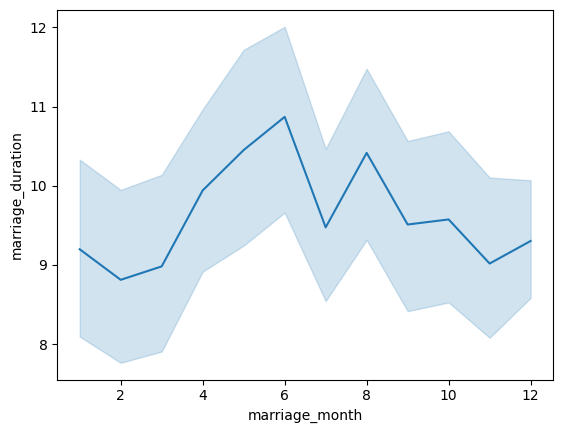

In [ ]:
sns.lineplot(data=df1, x='marriage_month', y='marriage_duration')
plt.show()

Podemos usar las variables `dob_man`y `dob_woman` para calcular la edad de hombre y mujer en cada matrimonio:

In [ ]:
#primero calculemos el día de hoy
today = pd.to_datetime('today')
today

Timestamp('2026-04-24 03:31:48.357606')

In [ ]:
# calculemos las edades
df1['age_man']=(today-df1['dob_man']).dt.days//365
df1['age_woman']=(today-df1['dob_woman']).dt.days//365

In [ ]:
df1.head()

,divorce_date,dob_man,education_man,income_man,dob_woman,education_woman,income_woman,marriage_date,marriage_duration,num_kids,have_kids,marriage_month,marriage_year,age_man,age_woman
0,2006-09-06,1975-12-18,Secondary,2000.0,1983-08-01,Secondary,1800.0,2000-06-26,5.0,1.0,si,6,2000,49,42
1,2008-01-02,1976-11-17,Professional,6000.0,1977-03-13,Professional,6000.0,2001-09-02,7.0,0.0,no,9,2001,48,48
2,2011-01-02,1969-04-06,Preparatory,5000.0,1970-02-16,Professional,5000.0,2000-02-02,2.0,2.0,si,2,2000,56,55
3,2011-01-02,1979-11-13,Secondary,12000.0,1981-05-13,Secondary,12000.0,2006-05-13,2.0,0.0,no,5,2006,45,44
4,2011-01-02,1982-09-20,Professional,6000.0,1988-01-30,Professional,10000.0,2007-08-06,3.0,0.0,no,8,2007,43,37


## Relaciones con variables categóricas

In [ ]:
df1['education_man'].value_counts()

,count
education_man,
Professional,1313
Preparatory,501
Secondary,288
Primary,100
Other,3


Las variables categóricas se utilizan a menudo para entender las numéricas y sus relaciones, por ejemplo para la variable *duracción de matrimonio*:

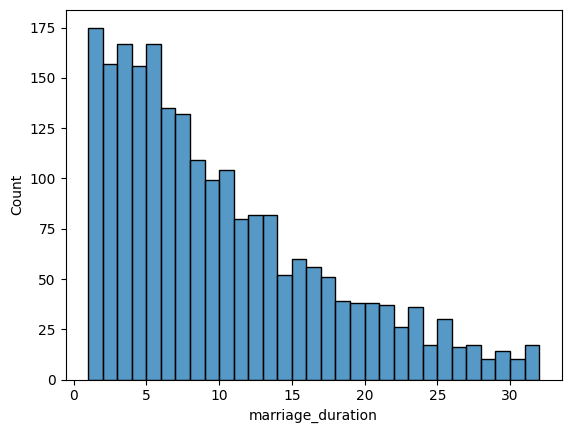

In [ ]:
sns.histplot(data=df1, x='marriage_duration', binwidth=1)
plt.show()

Nota que es limitado lo que se puede entender aquí (salvo quizas ver la distribución que sigue). Ahora usando las categorías:

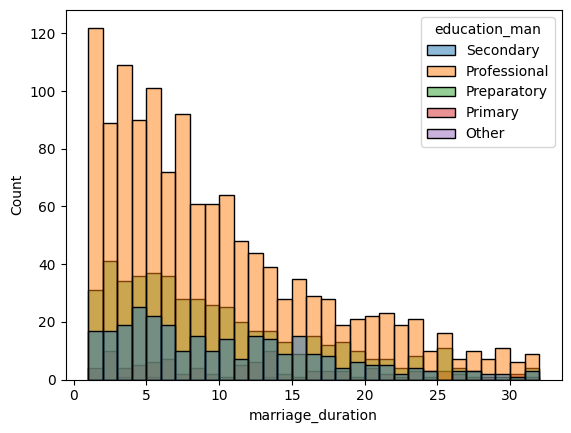

In [ ]:
sns.histplot(data=df1, x='marriage_duration', binwidth=1, hue='education_man')
plt.show()

También se puede usar la curva kde para analizarlo:

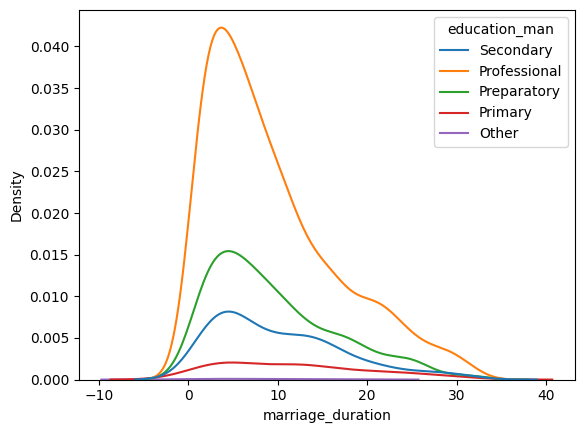

In [ ]:
sns.kdeplot(data=df1, x='marriage_duration',  hue='education_man')
plt.show()

Observa que aquí hay un detalle confuso y es para los valores negativos, para esto se puede usar el corte:

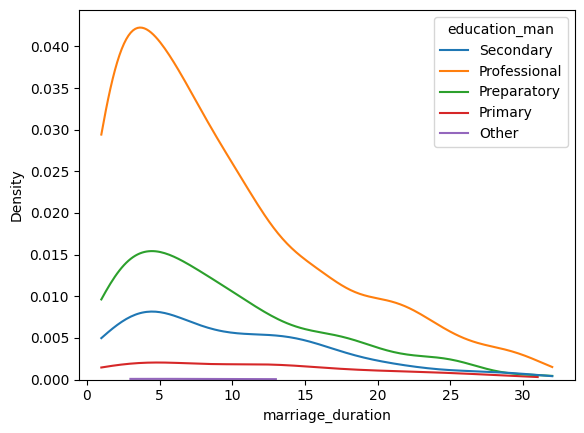

In [ ]:
sns.kdeplot(data=df1, x='marriage_duration',  hue='education_man', cut=0)
plt.show()

O acumulando:

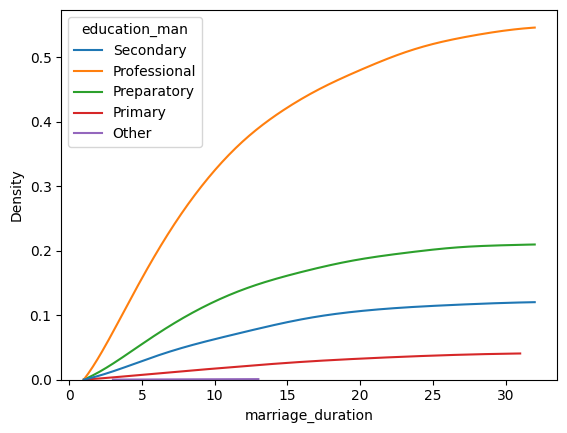

In [ ]:
sns.kdeplot(data=df1, x='marriage_duration',  hue='education_man', cut=0, cumulative=True)
plt.show()

También aplica para countplots

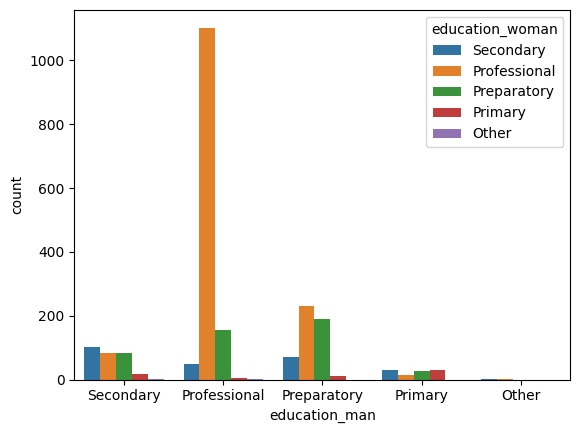

In [ ]:
sns.countplot(data=df1, x='education_man', hue='education_woman')
plt.show()

Esto también puede usar para entender relaciones numéricas con más de una variable:

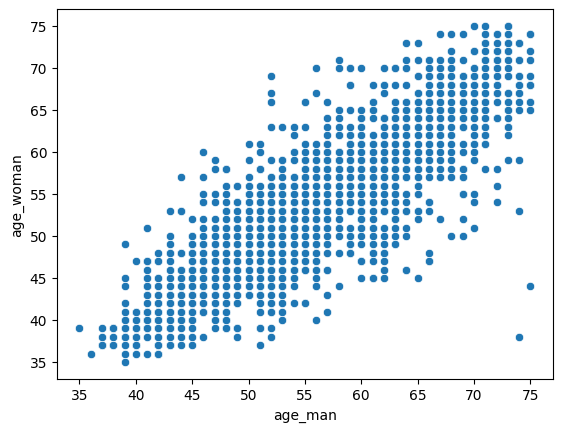

In [ ]:
sns.scatterplot(data=df1, x='age_man', y='age_woman')
plt.show()

Categorizado por si tiene hijos:

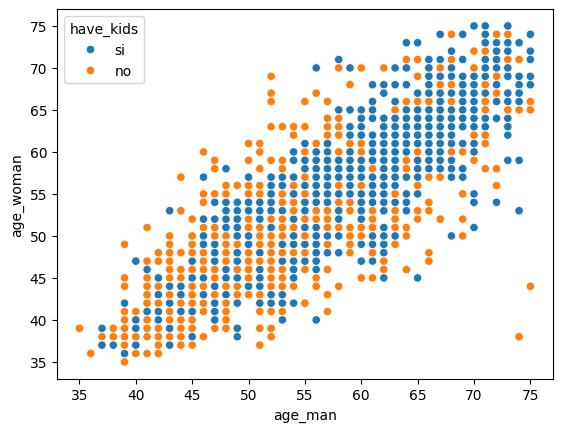

In [ ]:
sns.scatterplot(data=df1, x='age_man', y='age_woman', hue='have_kids')
plt.show()

Y por último en los pairplots:

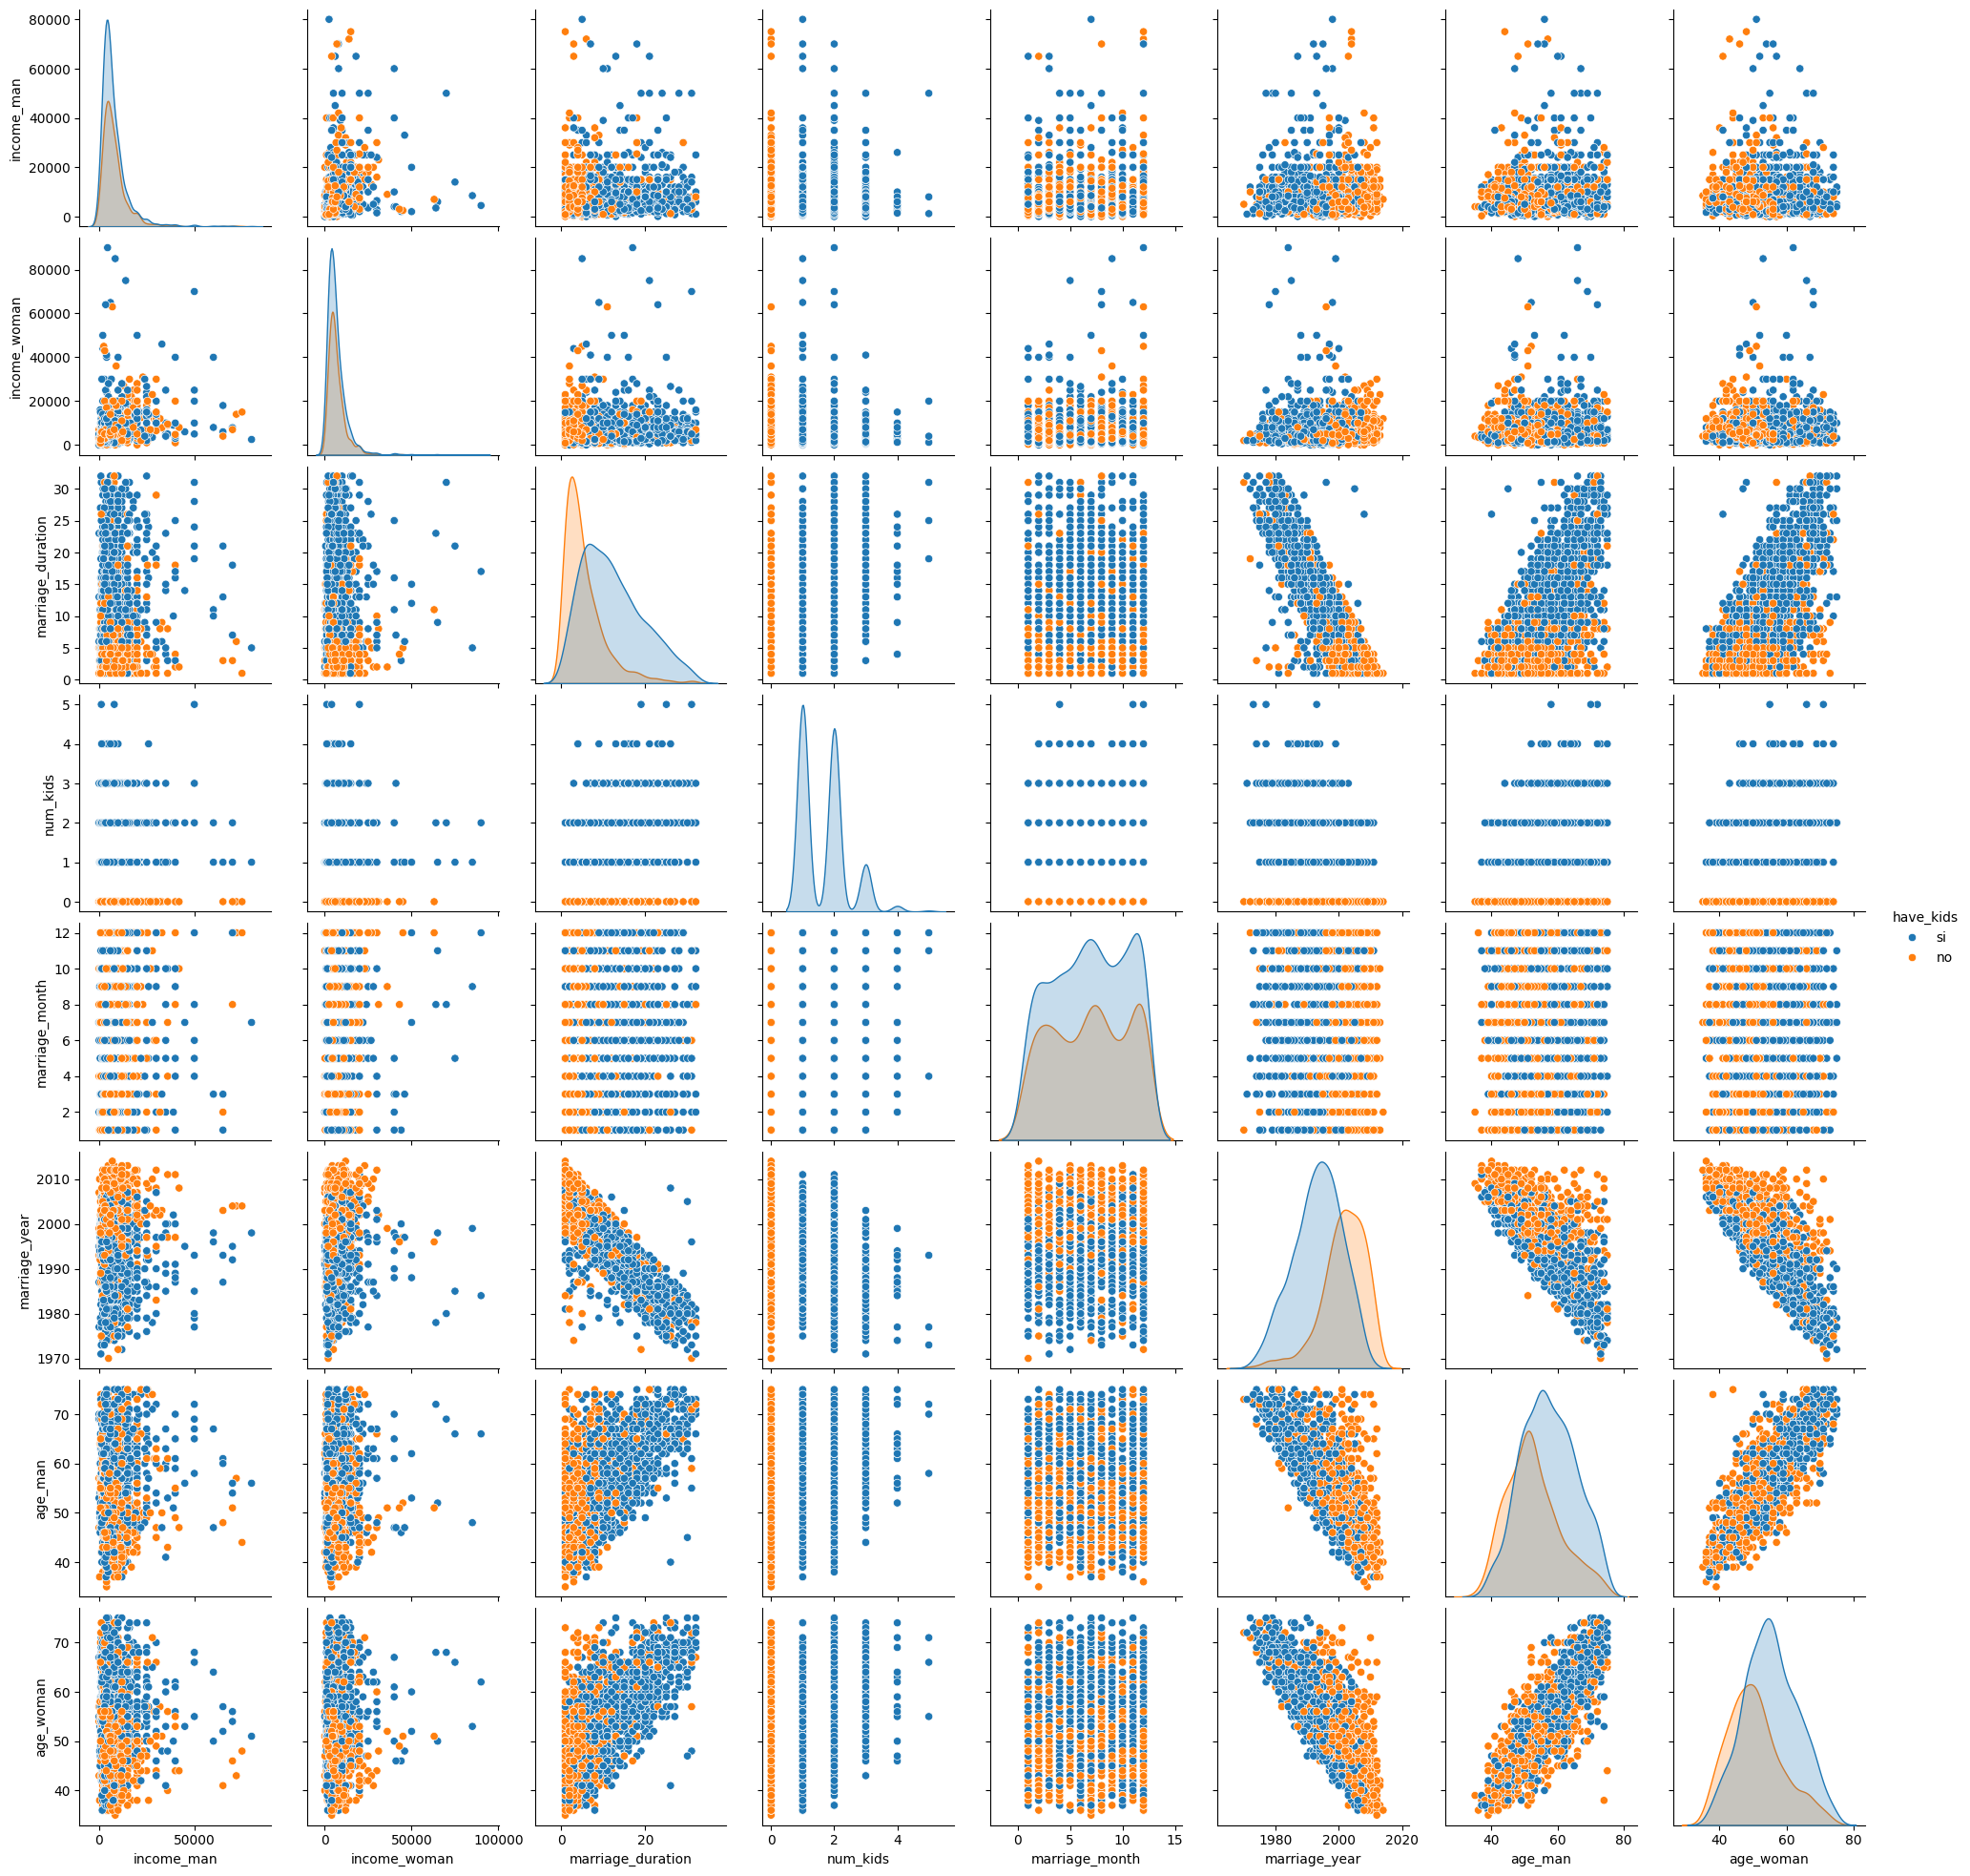

In [ ]:
sns.pairplot(data=df1, hue='have_kids')
plt.show()